# <span style="color:red"> **LSN - Esercitazione 02**
### <span style="color:green"> 13.03.2025
#### <span style="color:green"> Lucrezia Bioni (13655A)

Note:
#### Esercizio 02.1: 
- provare a fare importance sampling con una p(x) con una funzione molto diversa dall'integranda
- capire come mai errore oscilla così: errore nel codice?

#### Esercizio 02.2:
- fare punto 1
- fare punto 2


## <span style="color:blue">**Esercizio 02.1**

L'esercizio consiste nel calcolo del seguente integrale monodimensionale tramite metodo Monte Carlo:
$$I := \int_0^1 \frac{\pi}{2}\cos(\pi x/2) dx = 1$$

Inizialmente, si è effettuata una stima dell'integrale tramite metodo della media, con un **campionamento uniforme dell'intervallo [0,1)**. Tuttavia, tale scelta di distribizione di probabilità non è la migliore: infatti, si può ridurre significativamente l'incertezza sul risultato ottenuto ricorrendo a una distribuzione di probabilità che sia più simile all'integranda, al fine di campionare con più probabilità solo le zone effettivamente rilevanti, ovvero dove l'integranda assume valori maggiori. Questa è proprio l'idea alla base del metodo dell'**Importance Sampling**, che è stato utilizzato per fare una seconda stima dell'integrale. In particolare, si fattorizza l'integranda $f(x)$ nel prodotto $g(x) \cdot p(x)$, con $g(x):= \frac{f(x)}{p(x)}$

In entrambi i casi, si sono effettuate $M=10^5$ stime, suddivise in $N=100$ blocchi, e si sono calcolate le incertezze tramite data blocking.

2. Stima tramite importance sampling

Fattorizzo l'integranda in funzione su cui valutare i punti campionati e distribuzione di probabilità. Ottengo una buona stima della distribuzione di probabilità effettuando lo sviluppo di taylor dell'integranda attorno a x = 1. Questo dovrebbe darmi un buon risultato.

è molto più preciso del metodo precedente, come atteso. Migliore perché campiona di più dove ha più senso farlo.

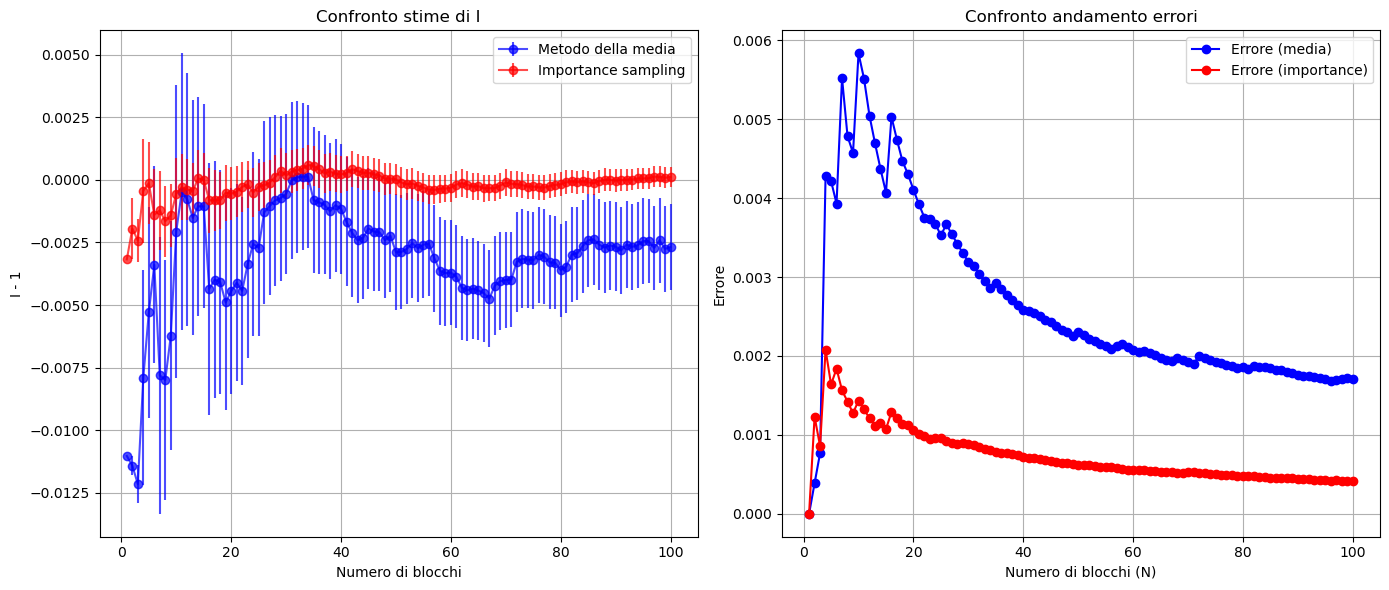

In [20]:
import matplotlib.pyplot as plt
import numpy as np

data_media = np.loadtxt("02.1/data_media.dat")
data_importance = np.loadtxt("02.1/data_importance.dat")

x_media = data_media[:, 0]
y_media = data_media[:, 2]
err_media = data_media[:, 3]

x_imp = data_importance[:, 0]
y_imp = data_importance[:, 2]
err_imp = data_importance[:, 3]

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.errorbar(x_media, y_media, yerr=err_media, fmt='bo-', label="Metodo della media", alpha=0.7)
plt.errorbar(x_imp, y_imp, yerr=err_imp, fmt='ro-', label="Importance sampling", alpha=0.7)
plt.xlabel("Numero di blocchi")
plt.ylabel("I - 1")
plt.title("Confronto stime di I")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(x_media, err_media, 'bo-', label="Errore (media)")
plt.plot(x_imp, err_imp, 'ro-', label="Errore (importance)")
#plt.plot(x_media, 1/np.sqrt(x_media), 'k--', label="$1/\sqrt{N}$ teorico")
plt.xlabel("Numero di blocchi (N)")
plt.ylabel("Errore")
plt.title("Confronto andamento errori")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

Si osserva che l'errore risulta significativamente ridotto tramite Importance Sampling. Tuttavia, si ottiene un risultato compatibile anche mediante Metodo della Media: si ottiene sempre, infatti, un valore che ricade entro $2 \sigma$ dal valore atteso.  Si osserva che l'errore ha un andamento $\approx \frac{1}{\sqrt{N}}$.

## <span style="color:blue">**Esercizio 02.2**

1. Simulo random walk tradizionale su un reticolo cubico con lattice constant a = 1. 